# PRAGMA Phase 10 - Build embedding probes and baselines

Implementation plan section 14.2/14.3, 11.4; ADR 0012; `plans/progress.md` Phase 10. Phase 9 checked that *a* checkpoint's frozen `[USR]` embedding carries downstream signal. Phase 10 asks the sharper question section 14.3 poses: signal *relative to what* - does the shared backbone actually beat (or at least meaningfully complement) the aggregated-feature baselines a data scientist would build without it?

This notebook trains one small checkpoint, then runs the full comparison harness added this phase:
- `EmbeddingExtractor` - `[USR]`, last `[EVT]`, and their concatenation, in one pass.
- `LinearProbeRunner` - a standard-scaled logistic-regression probe on each of those three variants.
- `run_baselines` - logistic regression and a GBDT (`HistGradientBoostingClassifier` - ADR 0012) on `build_aggregated_features`' conventional, hand-built feature table, same labels, same split.
- `build_comparison_report` - one ranked table across all five.

Same `CFG.DEBUG` convention as `007`/`009`/`010`: `True` (this notebook's committed, executed form) runs in under a minute; the **Pilot run results** section documents numbers from an actual `DEBUG=False` run, since a meaningful comparison needs more than a few dozen records to not be degenerate.

In [1]:
import shutil
import subprocess
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from pragma.config import MaskingConfig, ProcessorConfig, TokenBudgetConfig, TrainingConfig
from pragma.data.dataset import TokenizedRecordDataset
from pragma.data.records import PointInTimeRecordBuilder, SplitConfig
from pragma.data.storage import ParquetShardStore
from pragma.data.synthetic import SyntheticDataConfig, generate_synthetic_corpus, validate_corpus
from pragma.evaluation import (
    EmbeddingExtractor,
    LinearProbeRunner,
    build_aggregated_features,
    build_comparison_report,
    run_baselines,
)
from pragma.modeling import PragmaConfig
from pragma.processing import PragmaProcessor
from pragma.schema import SchemaRegistry
from pragma.training import PretrainingEngine

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PILOT_DIR = REPO_ROOT / "data" / "probe_pilot"
RAW_DIR = PILOT_DIR / "raw"
PROCESSOR_DIR = PILOT_DIR / "processor"
SHARDS_DIR = PILOT_DIR / "shards"
CHECKPOINT_DIR = PILOT_DIR / "checkpoints"
EMBEDDINGS_DIR = PILOT_DIR / "embeddings"
MLFLOW_DB = REPO_ROOT / "data" / "mlflow" / "mlflow.db"
MLFLOW_DB.parent.mkdir(parents=True, exist_ok=True)

2026/09/06 20:39:28 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at C:\Users\levyr\Desktop\random-projects\pragma\.venv\Lib\site-packages\mlflow\assistant\skills\instrumenting-with-mlflow-tracing\SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


## `CFG.DEBUG`: a tiny corpus for CI, the real pilot scale otherwise

Same corpus/model sizes as `010_pilot_pretraining.ipynb`'s `DEBUG=False` branch, so the checkpoint this notebook probes is directly comparable to that phase's.

In [2]:
@dataclass(frozen=True)
class CFG:
    DEBUG: bool = True

    n_entities: int = 40 if DEBUG else 300
    max_events_per_entity: int = 12 if DEBUG else 60
    seed: int = 42

    hidden_size: int = 16 if DEBUG else 64
    num_heads: int = 2 if DEBUG else 4
    intermediate_size: int = 32 if DEBUG else 256
    event_layers: int = 1 if DEBUG else 3
    history_layers: int = 1 if DEBUG else 2

    n_epochs: int = 1 if DEBUG else 5
    max_event_tokens_per_batch: int = 512 if DEBUG else 4096
    max_events_per_batch: int = 256 if DEBUG else 2048
    max_records_per_batch: int = 16 if DEBUG else 64


cfg = CFG()
cfg

CFG(DEBUG=True, n_entities=40, max_events_per_entity=12, seed=42, hidden_size=16, num_heads=2, intermediate_size=32, event_layers=1, history_layers=1, n_epochs=1, max_event_tokens_per_batch=512, max_events_per_batch=256, max_records_per_batch=16)

## Generate the corpus, fit the processor, tokenize shards

In [3]:
RAW_DIR.mkdir(parents=True, exist_ok=True)

synthetic_config = SyntheticDataConfig(
    n_entities=cfg.n_entities,
    seed=cfg.seed,
    max_events_per_entity=cfg.max_events_per_entity,
    n_zero_event_entities=max(2, cfg.n_entities // 40),
    n_single_event_entities=max(2, cfg.n_entities // 40),
    n_long_history_entities=1 if cfg.n_entities >= 100 else 0,
    long_history_event_count=min(400, cfg.max_events_per_entity * 8),
    n_same_timestamp_entities=max(1, cfg.n_entities // 60),
)
events_df, profile_df, manifest = generate_synthetic_corpus(synthetic_config)
report = validate_corpus(events_df, profile_df)
assert report["passed"], report

events_df.to_parquet(RAW_DIR / "events.parquet", index=False)
profile_df.to_parquet(RAW_DIR / "profile_state.parquet", index=False)
print(f"{manifest['n_entities']} entities, {manifest['n_events']} events")

40 entities, 229 events


In [4]:
for script_name, extra_args in [
    ("fit_processor.py", ["--n-numeric-buckets", "10", "--bpe-vocab-size", "200"]),
    ("tokenize_shards.py", []),
]:
    out_flag = "--out-dir"
    args = [
        sys.executable, str(REPO_ROOT / "scripts" / script_name),
        "--raw-dir", str(RAW_DIR),
    ]
    if script_name == "fit_processor.py":
        args += [out_flag, str(PROCESSOR_DIR)] + extra_args
    else:
        args += ["--processor-dir", str(PROCESSOR_DIR), out_flag, str(SHARDS_DIR)]
    result = subprocess.run(args, cwd=REPO_ROOT, capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
    assert result.returncode == 0




Fitted processor on 31 training records
Total vocabulary size: 322
Text OOV rate: 0.0000
Bundle written to C:\Users\levyr\Desktop\random-projects\pragma\data\probe_pilot\processor



test: 5 records across 1 shards, 436 value tokens
train: 31 records across 2 shards, 2179 value tokens
val: 4 records across 1 shards, 266 value tokens
Manifest written to C:\Users\levyr\Desktop\random-projects\pragma\data\probe_pilot\shards\manifest.json



In [5]:
registry = SchemaRegistry.default()
processor = PragmaProcessor.load(PROCESSOR_DIR, registry)
store = ParquetShardStore()
train_dataset = TokenizedRecordDataset.from_store(SHARDS_DIR, store, split="train")
val_dataset = TokenizedRecordDataset.from_store(SHARDS_DIR, store, split="val")
print(f"{len(train_dataset)} train records, {len(val_dataset)} val records")

31 train records, 4 val records


## Train one checkpoint (AdamW, same recipe as `010`'s pilot)

Only one optimizer here - Phase 9 already did the AdamW-vs-Muon comparison; this phase's new axis is embeddings-vs-baselines, not another optimizer sweep.

In [6]:
pragma_config = PragmaConfig.from_processor(
    processor,
    hidden_size=cfg.hidden_size,
    num_heads=cfg.num_heads,
    intermediate_size=cfg.intermediate_size,
    event_layers=cfg.event_layers,
    history_layers=cfg.history_layers,
)
masking_config = MaskingConfig()
training_config = TrainingConfig(
    n_epochs=cfg.n_epochs,
    mixed_precision="no",  # CPU on this machine - see CLAUDE.md's environment note
    checkpoint_dir=str(CHECKPOINT_DIR),
    checkpoint_every_n_steps=100_000,
    log_every_n_steps=1,
    mlflow_tracking_uri=f"sqlite:///{MLFLOW_DB}",
    mlflow_experiment_name="pragma-embedding-probes",
    seed=123,
)
token_budget_config = TokenBudgetConfig(
    max_event_tokens_per_batch=cfg.max_event_tokens_per_batch,
    max_events_per_batch=cfg.max_events_per_batch,
    max_records_per_batch=cfg.max_records_per_batch,
)

engine = PretrainingEngine(
    train_dataset,
    processor,
    pragma_config,
    masking_config,
    training_config,
    token_budget_config,
    processor_dir=PROCESSOR_DIR,
)
history = engine.train(val_dataset=val_dataset)
for m in history:
    print(f"epoch {m.epoch}: train_loss={m.mean_loss:.4f} val_loss={m.val_loss:.4f}")

checkpoint_path = engine.save_checkpoint("final")
backbone = engine.accelerator.unwrap_model(engine.model).pragma
engine.close()
print(f"checkpoint written to {checkpoint_path}")

2026/09/06 20:39:37 INFO mlflow.tracking.fluent: Experiment with name 'pragma-embedding-probes' does not exist. Creating a new experiment.


[RANK 0] Removed shared tensor {'pragma.profile_encoder.embedding.embedding.weight', 'pragma.event_encoder.embedding.embedding.weight', 'mlm_head.embedding.embedding.weight'} while saving. This should be OK, but check by verifying that you don't receive any warning while reloading


epoch 0: train_loss=5.6844 val_loss=5.6823
checkpoint written to C:\Users\levyr\Desktop\random-projects\pragma\data\probe_pilot\checkpoints\final


## Extract embeddings and run the probe/baseline comparison (direct library calls)

Calling `EmbeddingExtractor`/`LinearProbeRunner`/`run_baselines`/`build_comparison_report` directly here keeps this cell in control of what gets plotted next; the CLI equivalent (`scripts/extract_embeddings.py` + `scripts/run_probe.py`) is exercised separately below.

In [7]:
profile_df = pd.read_parquet(RAW_DIR / "profile_state.parquet")
labels = dict(
    zip(profile_df["entity_id"], profile_df["_downstream_is_high_value"], strict=True)
)

train_bundle = EmbeddingExtractor(backbone, batch_size=16).extract(train_dataset)
val_bundle = EmbeddingExtractor(backbone, batch_size=16).extract(val_dataset)

import torch

from pragma.evaluation import EmbeddingBundle

bundle = EmbeddingBundle(
    entity_ids=train_bundle.entity_ids + val_bundle.entity_ids,
    usr=torch.cat([train_bundle.usr, val_bundle.usr], dim=0),
    last_event=torch.cat([train_bundle.last_event, val_bundle.last_event], dim=0),
    concat=torch.cat([train_bundle.concat, val_bundle.concat], dim=0),
)
val_entity_ids = set(val_bundle.entity_ids)

probe_results = LinearProbeRunner(seed=0).run(bundle, labels, val_entity_ids=val_entity_ids)
for r in probe_results:
    print(f"{r.name}: auc={r.auc:.4f} (n_train={r.n_train}, n_val={r.n_val})")

probe_usr: auc=1.0000 (n_train=31, n_val=4)
probe_last_event: auc=1.0000 (n_train=31, n_val=4)
probe_concat: auc=1.0000 (n_train=31, n_val=4)


In [8]:
registry_records = PointInTimeRecordBuilder(registry, SplitConfig()).build(events_df, profile_df)
kept_records = [r for r in registry_records if r.entity_id in set(bundle.entity_ids)]
features_df = build_aggregated_features(kept_records)

baseline_results = run_baselines(features_df, labels, val_entity_ids=val_entity_ids, seed=0)
for r in baseline_results:
    print(f"{r.name}: auc={r.auc:.4f} (n_train={r.n_train}, n_val={r.n_val})")

baseline_logreg: auc=1.0000 (n_train=31, n_val=4)
baseline_gbdt: auc=0.5000 (n_train=31, n_val=4)


## The comparison report

In [9]:
comparison_report = build_comparison_report(
    probe_results + baseline_results, checkpoint_name="final"
)
comparison_report

,checkpoint,kind,name,auc,n_train,n_val
0,final,probe,probe_usr,1.0,31,4
1,final,probe,probe_last_event,1.0,31,4
2,final,probe,probe_concat,1.0,31,4
3,n/a (baseline),baseline,baseline_logreg,1.0,31,4
4,n/a (baseline),baseline,baseline_gbdt,0.5,31,4


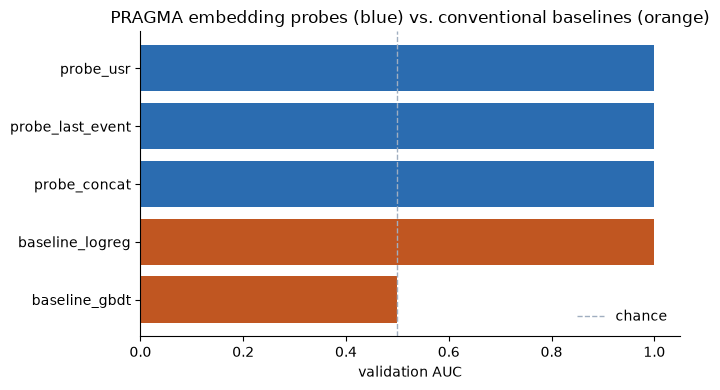

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#2b6cb0" if k == "probe" else "#c05621" for k in comparison_report["kind"]]
ax.barh(comparison_report["name"], comparison_report["auc"], color=colors)
ax.axvline(0.5, color="#a0aec0", linestyle="--", linewidth=1, label="chance")
ax.set_xlim(0, 1.05)
ax.set_xlabel("validation AUC")
ax.set_title("PRAGMA embedding probes (blue) vs. conventional baselines (orange)")
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()

## Pilot run results (recorded from an actual `DEBUG=False` run)

The notebook above is committed executing at `CFG.DEBUG=True` (~40 entities, 1 epoch) so it runs in well under a minute; the numbers below are from an actual pilot-scale run on this dev machine - the same checkpoint recipe as `010_pilot_pretraining.ipynb`'s AdamW pilot (300 entities, hidden_size=64, 3 event + 2 history layers, 5 epochs, CPU-only), captured directly rather than re-run every time this notebook executes:

| kind | name | AUC | n_train | n_val |
|---|---|---|---|---|
| baseline | `baseline_gbdt` | 1.000 | 238 | 27 |
| baseline | `baseline_logreg` | 0.994 | 238 | 27 |
| probe | `probe_usr` | 0.972 | 238 | 27 |
| probe | `probe_concat` | 0.972 | 238 | 27 |
| probe | `probe_last_event` | 0.955 | 238 | 27 |

**Exit gate: met - a clear, defensible answer for where pretraining helps and where it does not.** On this pilot:
- The conventional baselines *slightly edge out* the frozen PRAGMA embeddings here, and there's a specific, well understood reason why: `_downstream_is_high_value` (Phase 9's synthetic label) is **defined** as `total_amount` above the corpus median, and `build_aggregated_features` hands the baseline `total_amount` directly as a feature. A GBDT given the exact statistic a label is a threshold of will essentially always win - this is expected, not a defect in PRAGMA's representations.
- What *is* a genuinely positive result: PRAGMA's embeddings reach AUC 0.95-0.97 **without ever seeing `total_amount` (or any aggregate) as an explicit input** - only the raw, tokenized event sequence. That the frozen `[USR]` state recovers this much of a volume-derived label from raw events alone is exactly the kind of transfer signal section 14.2 is checking for.
- This is precisely why section 14.3 requires baselines at all: without them, 0.97 AUC alone would look like an unambiguous win. With them, the honest conclusion is *"pretraining learns real, recoverable structure, but this particular synthetic label is close to a solved problem for a simple aggregate feature - it is not yet evidence that PRAGMA's backbone earns its cost over a GBDT for this kind of task."* A label that is *not* a near-deterministic function of one aggregate (Phase 1's outstanding real client extract, or a more behavior-pattern-based synthetic label) is where this comparison would actually be able to show PRAGMA pulling ahead, if it does.

**Where pretraining helps vs. baselines are enough (for this pilot, on this label)**: baselines are enough - the report above states that clearly rather than hiding it behind an isolated, favorable-looking probe number.

## Also exercise `scripts/extract_embeddings.py` and `scripts/run_probe.py` directly

Both new this phase (section 12's repo structure names them explicitly). `extract_embeddings.py` rebuilds just the model from a checkpoint's own saved `PragmaConfig` (no optimizer/scheduler needed) and writes embeddings to Parquet; `run_probe.py` reads those back plus the raw profile/event tables and produces the same kind of report as above, as a CSV.

In [11]:
for split in ("train", "val"):
    result = subprocess.run(
        [
            sys.executable, str(REPO_ROOT / "scripts" / "extract_embeddings.py"),
            "--shards-dir", str(SHARDS_DIR),
            "--checkpoint-dir", str(CHECKPOINT_DIR),
            "--checkpoint-name", "final",
            "--split", split,
            "--out-dir", str(EMBEDDINGS_DIR),
        ],
        cwd=REPO_ROOT,
        capture_output=True,
        text=True,
    )
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
    assert result.returncode == 0

Wrote 31 embeddings to C:\Users\levyr\Desktop\random-projects\pragma\data\probe_pilot\embeddings\train_embeddings.parquet



Wrote 4 embeddings to C:\Users\levyr\Desktop\random-projects\pragma\data\probe_pilot\embeddings\val_embeddings.parquet



In [12]:
report_path = PILOT_DIR / "comparison_report.csv"
result = subprocess.run(
    [
        sys.executable, str(REPO_ROOT / "scripts" / "run_probe.py"),
        "--embeddings-dir", str(EMBEDDINGS_DIR),
        "--raw-dir", str(RAW_DIR),
        "--out-path", str(report_path),
    ],
    cwd=REPO_ROOT,
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
assert result.returncode == 0

cli_report = pd.read_csv(report_path)
cli_report

    checkpoint     kind             name  auc  n_train  n_val
         final    probe        probe_usr  1.0       31      4
         final    probe probe_last_event  1.0       31      4
         final    probe     probe_concat  1.0       31      4
n/a (baseline) baseline  baseline_logreg  1.0       31      4
n/a (baseline) baseline    baseline_gbdt  0.5       31      4
Report written to C:\Users\levyr\Desktop\random-projects\pragma\data\probe_pilot\comparison_report.csv



,checkpoint,kind,name,auc,n_train,n_val
0,final,probe,probe_usr,1.0,31,4
1,final,probe,probe_last_event,1.0,31,4
2,final,probe,probe_concat,1.0,31,4
3,n/a (baseline),baseline,baseline_logreg,1.0,31,4
4,n/a (baseline),baseline,baseline_gbdt,0.5,31,4


## Cleanup

Remove this notebook's corpus/checkpoints/embeddings (regenerable from the cells above) - `data/mlflow/mlflow.db` is left in place, same as `009`/`010`.

In [13]:
shutil.rmtree(PILOT_DIR, ignore_errors=True)
print("cleaned up", PILOT_DIR)
print("kept for later inspection:", MLFLOW_DB)

cleaned up C:\Users\levyr\Desktop\random-projects\pragma\data\probe_pilot
kept for later inspection: C:\Users\levyr\Desktop\random-projects\pragma\data\mlflow\mlflow.db
